In [1]:
!pip install -U scikit-learn==1.5.0
!pip install -U imbalanced-learn==0.13.0
!pip install polars[numpy,pandas,pyarrow] --no-index --find-links=file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 53.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Looking in links: file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg
Processing /kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg/polars-0.20.16-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl


In [2]:
import sklearn
import imblearn
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
import os
import polars as pl
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import pickle
import ctypes
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

print("scikit-learn version:", sklearn.__version__)
print("imblearn version:", imblearn.__version__)

E0000 00:00:1746883285.082760      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


scikit-learn version: 1.5.0
imblearn version: 0.13.0


In [3]:
# detect TPUs
tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
tf.tpu.experimental.initialize_tpu_system(tpu)
tpu_strategy = tf.distribute.TPUStrategy(tpu)

print("Number of accelerators: ", tpu_strategy.num_replicas_in_sync)

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1746883305.941139      10 service.cc:148] XLA service 0x57d70cf38960 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746883305.941183      10 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1746883305.941187      10 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1746883305.941189      10 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1746883305.941192      10 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1746883305.941194      10 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1746883305.941197      10 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1746883305.941199      10 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1746883305.941201      10 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [4]:
feature_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/extracted_train_feat_five_sec_v5_2025'
label_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/labels_five_sec_v5_2025'

missing_classes_feature_file_path = '/kaggle/input/missing-classes-features-labels/late_inclusion_features_2025'
missing_classes_label_file_path = '/kaggle/input/missing-classes-features-labels/late_inclusion_labels_2025'

with open(feature_file_path, "rb") as file:
    pickled_extracted_features_five_sec = pickle.load(file)
    
with open(label_file_path, "rb") as file:
    labels_five_sec = pickle.load(file)

with open(missing_classes_feature_file_path, "rb") as file:
    pickled_missing_classes_features_five_sec = pickle.load(file)
    
with open(missing_classes_label_file_path, "rb") as file:
    labels_missing_classes_five_sec = pickle.load(file)

x_five_sec = np.vstack([pickled_extracted_features_five_sec, pickled_missing_classes_features_five_sec])
y_five_sec = np.concatenate([labels_five_sec, labels_missing_classes_five_sec], axis=0)

print("Combined features shape:", x_five_sec.shape)
print("Combined labels shape:", y_five_sec.shape)

Combined features shape: (180762, 40)
Combined labels shape: (180762,)


In [5]:
ros = RandomOverSampler(random_state=42, sampling_strategy='minority')
features_resampled, labels_resampled = ros.fit_resample(x_five_sec, y_five_sec)

print("Resampled features shape:", features_resampled.shape)
print("Resampled labels shape:", labels_resampled.shape)

Resampled features shape: (186377, 40)
Resampled labels shape: (186377,)


In [6]:
shuffle_idx = np.random.permutation(len(features_resampled))
X_combined = features_resampled[shuffle_idx]
y_combined = labels_resampled[shuffle_idx]

In [27]:
def prepare_dataset(X, y, batch_size=32):
    """
    Convert numpy arrays to tf.data.Dataset with batching and prefetching
    """
    min_label = np.min(y)
    max_label = np.max(y)
    unique_labels = np.unique(y)
    print(f"****** dataset size**********: {X.shape}")
    print(f"Label range: {min_label} to {max_label}")
    print(f"Number of unique labels: {len(unique_labels)}")
    #print(f"Unique labels: {unique_labels}")
    
    # Robust normalization using min-max scaling instead of standard scaling
    """X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-8)"""

    # Normalize features
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0) + 1e-8
    X_normalized = (X - X_mean) / X_std

    # Convert to float32 for TPU
    X_normalized = X_normalized.astype(np.float32)
    
    # Ensure y is 1D array of integers
    y = np.asarray(y).astype(np.int32).ravel()
    
    # Get number of classes
    num_classes = max_label + 1
    print(f"Number of unique classes in this split: {num_classes}")
    
    # Double check normalization
    print("After normalization:")
    print("Min:", np.min(X_normalized))
    print("Max:", np.max(X_normalized))
    print("Mean:", np.mean(X_normalized))
    print("Std:", np.std(X_normalized))
    
    # Convert to one-hot encoding
    y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes)
    print(f"One-hot encoded shape: {y_onehot.shape}")
    
    # Verify one-hot encoding
    print("Sample of one-hot encoded labels:")
    print(y_onehot[:5])
    print("\nOriginal labels:", y[:5])
    
    # Create tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((X_normalized, y_onehot))
    #dataset = tf.data.Dataset.from_tensor_slices((X_normalized, y))
    dataset = dataset.cache()  # Cache the data in memory
    dataset = dataset.shuffle(buffer_size=len(X))  # Shuffle the entire dataset
    dataset = dataset.batch(batch_size)  # Batch the data
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Prefetch next batch
    
    return dataset

In [8]:
# Let's verify the data before training
def verify_data(X, y):
    print("Input features:")
    print(f"Shape: {X.shape}")
    print(f"Data type: {X.dtype}")
    print(f"Any NaN: {np.isnan(X).any()}")
    print(f"Any Inf: {np.isinf(X).any()}")
    print(f"Range: [{np.min(X)}, {np.max(X)}]")
    
    print("\nLabels:")
    print(f"Shape: {y.shape}")
    print(f"Data type: {y.dtype}")
    print(f"Unique values: {np.unique(y)}")
    print(f"Number of classes: {len(np.unique(y))}")
    
    # Check class distribution
    unique, counts = np.unique(y, return_counts=True)
    print("\nClass distribution:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} samples")

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X_combined, y_combined, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

In [28]:
# Prepare datasets
train_dataset = prepare_dataset(X_train, y_train, batch_size=64)
val_dataset = prepare_dataset(X_val, y_val, batch_size=64)
test_dataset = prepare_dataset(X_test, y_test, batch_size=64)

****** dataset size**********: (111826, 40)
Label range: 0 to 205
Number of unique labels: 205
Number of unique classes in this split: 206
After normalization:
Min: -8.948927
Max: 8.786282
Mean: 1.3439272e-06
Std: 1.0000085
One-hot encoded shape: (111826, 206)
Sample of one-hot encoded labels:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Original labels: [187 205  43 131  66]
****** dataset size**********: (59640, 40)
Label range: 0 to 205
Number of unique labels: 202
Number of unique classes in this split: 206
After normalization:
Min: -8.638403
Max: 8.75684
Mean: -6.691263e-07
Std: 1.0000017
One-hot encoded shape: (59640, 206)
Sample of one-hot encoded labels:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Original labels: [172  97 132  61 129]
****** dataset size**********: (14911, 40)
Label range: 0 to 205
Number of unique

In [35]:
def create_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        #layers.Flatten(),
        layers.BatchNormalization(name='batch_norm_input'),
        
        layers.Dense(506, activation='selu', kernel_initializer='lecun_normal', name='dense_1'),
        layers.BatchNormalization(name='batch_norm_1'),
        #layers.Dropout(0.4),
        
        layers.Dense(406, activation='selu', kernel_initializer='lecun_normal', name='dense_2'),
        layers.BatchNormalization(name='batch_norm_2'),
        #layers.Dropout(0.3),
        
        layers.Dense(306, activation='selu', kernel_initializer='lecun_normal', name='dense_3'),
        layers.BatchNormalization(name='batch_norm_3'),
        #layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

In [30]:
input_shape = (X_train.shape[1],)  # Will be (40,)
num_classes = 206
print(input_shape)

(40,)


In [31]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='accuracy',
        mode='max',
        patience=15,
        restore_best_weights=True,
        min_delta=1e-4
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

In [ ]:
with tpu_strategy.scope():
    model = create_model(input_shape, num_classes)
    #model_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',  # Use this since we have one-hot encoded labels
        metrics=['accuracy']
    )

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_norm_input                │ (None, 40)             │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 506)            │        20,746 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 506)            │         2,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 406)            │       205,842 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 406)            │         1,624 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 306)            │       124,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 306)            │         1,224 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 206)            │        63,242 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,404 (1.60 MB)

 Trainable params: 416,888 (1.59 MB)

 Non-trainable params: 2,516 (9.83 KB)

In [39]:
def verify_batch(dataset):
    for features, labels in dataset.take(1):
        print("\nBatch verification:")
        print(f"Features shape: {features.shape}")
        print(f"Labels shape: {labels.shape}")
        print(f"Features dtype: {features.dtype}")
        print(f"Labels dtype: {labels.dtype}")
        print("\nSample labels from batch:")
        print(labels[:5])
        print("\nVerifying one-hot encoding (sum should be 1 for each row):")
        print(tf.reduce_sum(labels, axis=1)[:5])
        break

# Use this after creating your datasets
verify_batch(train_dataset)
verify_batch(val_dataset)


Batch verification:
Features shape: (64, 40)
Labels shape: (64, 206)
Features dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'float64'>

Sample labels from batch:
tf.Tensor(
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(5, 206), dtype=float64)

Verifying one-hot encoding (sum should be 1 for each row):
tf.Tensor([1. 1. 1. 1. 1.], shape=(5,), dtype=float64)

Batch verification:
Features shape: (64, 40)
Labels shape: (64, 206)
Features dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'float64'>

Sample labels from batch:
tf.Tensor(
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(5, 206), dtype=float64)

Verifying one-hot encoding (sum should be 1 for each row):
tf.Tensor([1. 1. 1. 1. 1.], shape=(5,), dtype=float64)


In [38]:
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

ValueError: Dimensions must be equal, but are 206 and 8 for '{{node Equal_1}} = Equal[T=DT_FLOAT, incompatible_shape_error=true](Cast, Cast_1)' with input shapes: [8,206], [8].

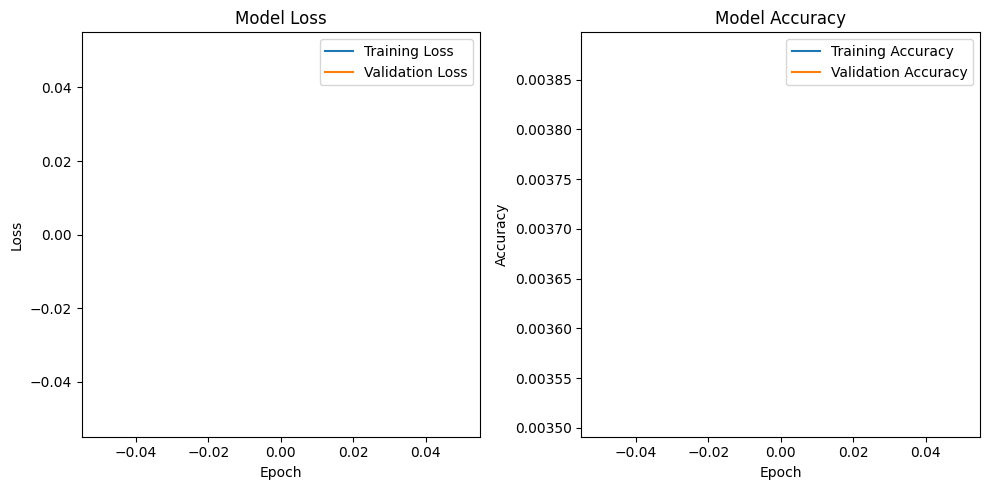

In [82]:
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()